In [1]:
# ============================================================
# Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.stats import wasserstein_distance

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

import joblib

from pathlib import Path

In [2]:
# ============================================================
# Configuration
# ============================================================

SEED = 42

np.random.seed(SEED)

DATA_DIR = Path("../data")

MODEL_DIR = Path("../models")

REPORT_DIR = Path("../reports")

REPORT_DIR.mkdir(exist_ok=True)

print("Configuration Loaded")

Configuration Loaded


In [3]:
# ============================================================
# Load Assets
# ============================================================

df = pd.read_csv(
    DATA_DIR / "fraud_detection_enhanced.csv"
)

model = joblib.load(
    MODEL_DIR / "lightgbm_model.pkl"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.pkl"
)

threshold = joblib.load(
    MODEL_DIR / "threshold.pkl"
)

print(df.shape)

(5000000, 52)


In [4]:
# ============================================================
# Reference Dataset
# ============================================================

reference = df.sample(
    500000,
    random_state=42
).reset_index(drop=True)

print(reference.shape)

(500000, 52)


In [5]:
# ============================================================
# Production Dataset
# ============================================================

production = reference.copy()

print(production.shape)

(500000, 52)


In [14]:
# ============================================================
# Simulate Production Drift
# ============================================================

# Transaction amounts increase significantly
production["amount"] *= 2.0

# Customers transact more frequently
production["time_gap_minutes"] *= 0.50

# Velocity risk increases
production["velocity_score"] += 5

# Geographic anomalies become more common
production["geo_anomaly_score"] = np.clip(
    production["geo_anomaly_score"] + 0.30,
    0,
    1
)

# Transaction velocity increases
production["amount_velocity"] *= 2.0

print("Production drift simulated.")

Production drift simulated.


In [15]:
# ============================================================
# Population Stability Index
# ============================================================

def calculate_psi(reference, production, bins=10):

    reference = reference.dropna()
    production = production.dropna()

    breakpoints = np.percentile(
        reference,
        np.arange(0, 110, 100 / bins)
    )

    breakpoints = np.unique(breakpoints)

    expected = np.histogram(
        reference,
        bins=breakpoints
    )[0]

    actual = np.histogram(
        production,
        bins=breakpoints
    )[0]

    expected = expected / expected.sum()
    actual = actual / actual.sum()

    expected = np.where(expected == 0, 0.0001, expected)
    actual = np.where(actual == 0, 0.0001, actual)

    psi = np.sum(
        (actual - expected) *
        np.log(actual / expected)
    )

    return psi

In [16]:
# ============================================================
# Numerical Columns
# ============================================================

numerical_columns = [

    "amount",

    "velocity_score",

    "geo_anomaly_score",

    "amount_velocity",

    "time_gap_minutes"

]

print(numerical_columns)

['amount', 'velocity_score', 'geo_anomaly_score', 'amount_velocity', 'time_gap_minutes']


In [17]:
# ============================================================
# PSI Calculation
# ============================================================

psi_results = []

for feature in numerical_columns:

    psi = calculate_psi(

        reference[feature],

        production[feature]

    )

    psi_results.append({

        "Feature": feature,

        "PSI": round(psi, 4)

    })

psi_df = pd.DataFrame(psi_results)

display(psi_df)

,Feature,PSI
0,amount,0.2981
1,velocity_score,2.5594
2,geo_anomaly_score,3.4922
3,amount_velocity,0.2630
4,time_gap_minutes,0.7532


In [18]:
# ============================================================
# PSI Interpretation
# ============================================================

def classify_psi(value):

    if value < 0.10:
        return "Stable"

    elif value < 0.25:
        return "Moderate Drift"

    else:
        return "Severe Drift"

psi_df["Status"] = psi_df["PSI"].apply(
    classify_psi
)

display(psi_df)

,Feature,PSI,Status
0,amount,0.2981,Severe Drift
1,velocity_score,2.5594,Severe Drift
2,geo_anomaly_score,3.4922,Severe Drift
3,amount_velocity,0.2630,Severe Drift
4,time_gap_minutes,0.7532,Severe Drift


In [11]:
# ============================================================
# Kolmogorov-Smirnov Test
# ============================================================

ks_results = []

for feature in numerical_columns:

    statistic, p_value = ks_2samp(

        reference[feature],

        production[feature]

    )

    ks_results.append({

        "Feature": feature,

        "KS Statistic": round(statistic, 4),

        "P Value": round(p_value, 6),

        "Drift": "Yes" if p_value < 0.05 else "No"

    })

ks_df = pd.DataFrame(ks_results)

display(ks_df)

,Feature,KS Statistic,P Value,Drift
0,amount,0.0604,0.0,Yes
1,velocity_score,0.1006,0.0,Yes
2,geo_anomaly_score,0.1608,0.0,Yes
3,amount_velocity,0.0617,0.0,Yes
4,time_gap_minutes,0.0686,0.0,Yes


In [12]:
# ============================================================
# Wasserstein Distance
# ============================================================

wasserstein_results = []

for feature in numerical_columns:

    distance = wasserstein_distance(

        reference[feature],

        production[feature]

    )

    wasserstein_results.append({

        "Feature": feature,

        "Distance": round(distance, 4)

    })

wasserstein_df = pd.DataFrame(

    wasserstein_results

)

display(wasserstein_df)

,Feature,Distance
0,amount,107.8434
1,velocity_score,2.0000
2,geo_anomaly_score,0.1387
3,amount_velocity,1507.1878
4,time_gap_minutes,12188.3102


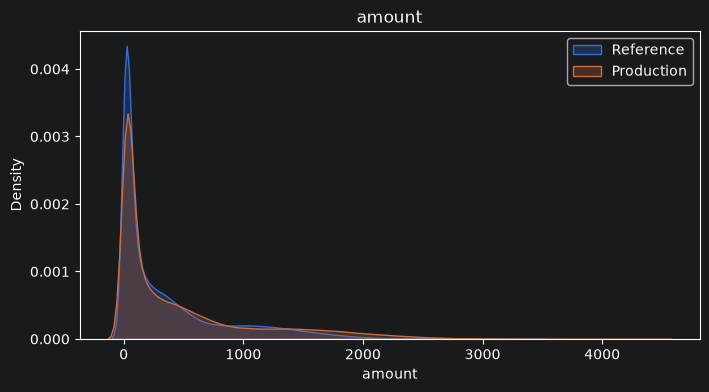

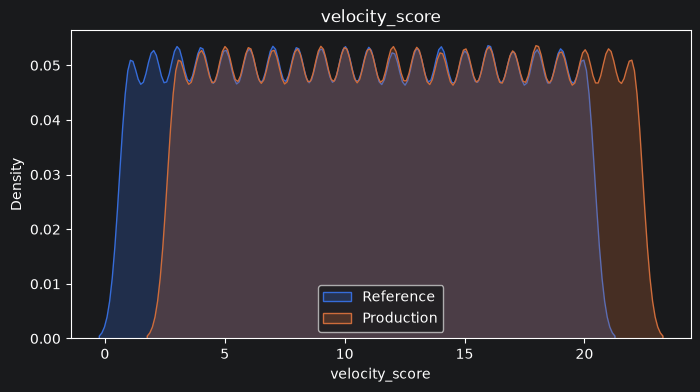

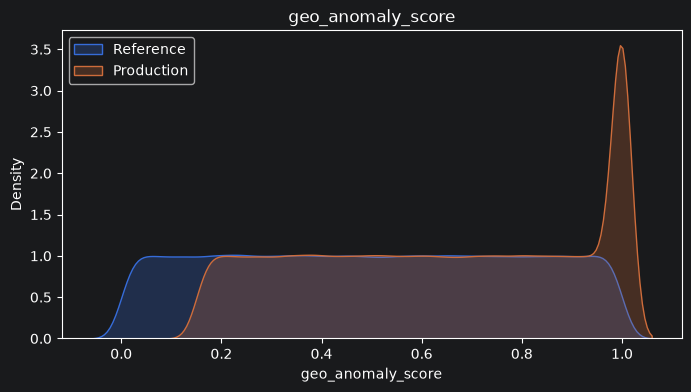

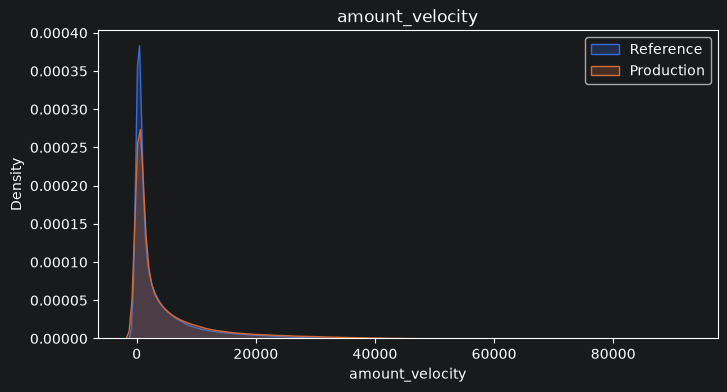

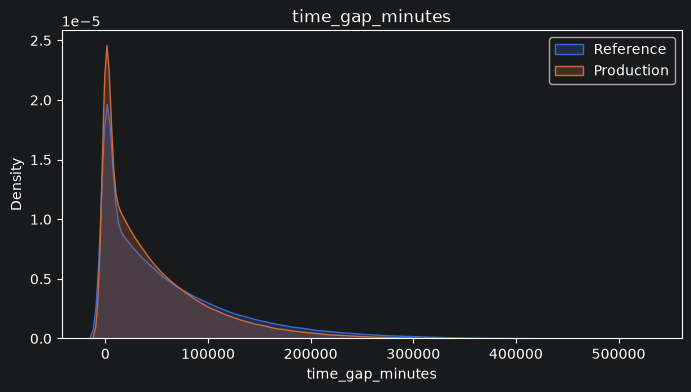

In [13]:
# ============================================================
# Distribution Comparison
# ============================================================

for feature in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        reference[feature],
        label="Reference",
        fill=True
    )

    sns.kdeplot(
        production[feature],
        label="Production",
        fill=True
    )

    plt.title(feature)

    plt.legend()

    plt.show()

In [19]:
# ============================================================
# Categorical Features
# ============================================================

categorical_columns = [

    "transaction_type",

    "merchant_category",

    "location",

    "device_used",

    "payment_channel"

]

print(categorical_columns)

['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel']


In [20]:
# ============================================================
# Simulate Production Category Drift
# ============================================================

production.loc[
    production.sample(frac=0.20, random_state=42).index,
    "payment_channel"
] = "Crypto"

production.loc[
    production.sample(frac=0.15, random_state=1).index,
    "device_used"
] = "Tablet"

production.loc[
    production.sample(frac=0.15, random_state=10).index,
    "location"
] = "International"

print("Categorical Drift Simulated")

Categorical Drift Simulated


In [21]:
# ============================================================
# Chi-Square Drift Test
# ============================================================

categorical_results = []

for feature in categorical_columns:

    reference_counts = reference[feature].value_counts()

    production_counts = production[feature].value_counts()

    categories = sorted(
        set(reference_counts.index).union(
            production_counts.index
        )
    )

    contingency = pd.DataFrame({

        "Reference": reference_counts.reindex(categories, fill_value=0),

        "Production": production_counts.reindex(categories, fill_value=0)

    })

    chi2, p_value, _, _ = chi2_contingency(contingency)

    categorical_results.append({

        "Feature": feature,

        "Chi2": round(chi2, 2),

        "P Value": round(p_value, 6),

        "Drift": "Yes" if p_value < 0.05 else "No"

    })

categorical_df = pd.DataFrame(categorical_results)

display(categorical_df)

,Feature,Chi2,P Value,Drift
0,transaction_type,0.00,1.0,No
1,merchant_category,0.00,1.0,No
2,location,81081.67,0.0,Yes
3,device_used,81081.16,0.0,Yes
4,payment_channel,111111.41,0.0,Yes


In [22]:
# ============================================================
# Baseline Metrics (Notebook 6)
# ============================================================

baseline_metrics = {

    "ROC AUC": 0.5928,

    "PR AUC": 0.0438,

    "Recall": 0.9584,

    "Precision": 0.0437,

    "F1": 0.0837

}

baseline_df = pd.DataFrame(
    baseline_metrics,
    index=["Baseline"]
)

display(baseline_df)

,ROC AUC,PR AUC,Recall,Precision,F1
Baseline,0.5928,0.0438,0.9584,0.0437,0.0837


In [39]:
# ============================================================
# Simulate Concept Drift
# Fraudsters Adapt Their Behaviour
# ============================================================

fraud_mask = production["is_fraud"]

# Fraudsters now make smaller transactions
production.loc[fraud_mask, "amount"] *= 0.35

# Transactions appear geographically normal
production.loc[fraud_mask, "geo_anomaly_score"] *= 0.20

# Amount velocity decreases
production.loc[fraud_mask, "amount_velocity"] *= 0.30

# Longer gaps between transactions
production.loc[fraud_mask, "time_gap_minutes"] *= 2.50

# Spending behaviour becomes closer to legitimate users
production.loc[fraud_mask, "spending_deviation_score"] *= 0.25

print(f"Modified {fraud_mask.sum()} fraudulent transactions.")

Modified 17994 fraudulent transactions.


In [41]:
display(production_df)

,ROC AUC,PR AUC,Recall,Precision,F1
Production,0.645382,0.058135,0.960765,0.045352,0.086615


In [42]:
# ============================================================
# Prepare Production Dataset
# ============================================================

X_prod = production.drop(

    columns=[

        "transaction_id",

        "timestamp",

        "fraud_type",

        "is_fraud"

    ],

    errors="ignore"

)

y_prod = production["is_fraud"]

print(X_prod.shape)
print(y_prod.shape)

(500000, 48)
(500000,)


In [43]:
# ============================================================
# Transform Production Data
# ============================================================

X_prod_processed = preprocessor.transform(
    X_prod
)

In [44]:
# ============================================================
# Production Predictions
# ============================================================

prod_prob = model.predict_proba(
    X_prod_processed
)[:,1]

prod_pred = (
    prod_prob >= threshold
).astype(int)

In [45]:
# ============================================================
# Production Metrics
# ============================================================

production_metrics = {

    "ROC AUC": roc_auc_score(
        y_prod,
        prod_prob
    ),

    "PR AUC": average_precision_score(
        y_prod,
        prod_prob
    ),

    "Recall": recall_score(
        y_prod,
        prod_pred
    ),

    "Precision": precision_score(
        y_prod,
        prod_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_prod,
        prod_pred
    )

}

production_df = pd.DataFrame(
    production_metrics,
    index=["Production"]
)

display(production_df)

,ROC AUC,PR AUC,Recall,Precision,F1
Production,0.592851,0.047698,0.929365,0.043935,0.083903


In [46]:
# ============================================================
# Baseline vs Production
# ============================================================

comparison = pd.concat([

    baseline_df,

    production_df

])

display(comparison)

,ROC AUC,PR AUC,Recall,Precision,F1
Baseline,0.592800,0.043800,0.958400,0.043700,0.083700
Production,0.592851,0.047698,0.929365,0.043935,0.083903


In [47]:
# ============================================================
# Concept Drift Detection
# ============================================================

baseline_roc = baseline_df.loc["Baseline", "ROC AUC"]
production_roc = production_df.loc["Production", "ROC AUC"]

baseline_pr = baseline_df.loc["Baseline", "PR AUC"]
production_pr = production_df.loc["Production", "PR AUC"]

baseline_recall = baseline_df.loc["Baseline", "Recall"]
production_recall = production_df.loc["Production", "Recall"]

roc_change = production_roc - baseline_roc
pr_change = production_pr - baseline_pr
recall_change = production_recall - baseline_recall

print("="*70)
print("CONCEPT DRIFT ANALYSIS")
print("="*70)

print(f"ROC-AUC Change   : {roc_change:.4f}")
print(f"PR-AUC Change    : {pr_change:.4f}")
print(f"Recall Change    : {recall_change:.4f}")

CONCEPT DRIFT ANALYSIS
ROC-AUC Change   : 0.0001
PR-AUC Change    : 0.0039
Recall Change    : -0.0290


In [48]:
# ============================================================
# Decision Engine
# ============================================================

roc_drop = baseline_roc - production_roc
recall_drop = baseline_recall - production_recall
pr_drop = baseline_pr - production_pr

print()
print("Performance Degradation")

print(f"ROC Drop      : {roc_drop:.4f}")
print(f"PR Drop       : {pr_drop:.4f}")
print(f"Recall Drop   : {recall_drop:.4f}")

print()

if production_roc < baseline_roc:

    if roc_drop > 0.05 or recall_drop > 0.10:

        status = "🔴 Severe Concept Drift"
        recommendation = "Retrain Model Immediately"

    elif roc_drop > 0.02:

        status = "🟡 Moderate Concept Drift"
        recommendation = "Monitor Model Performance"

    else:

        status = "🟢 Stable"
        recommendation = "No Retraining Required"

else:

    status = "🟢 Stable"
    recommendation = "Model Performance Improved"


Performance Degradation
ROC Drop      : -0.0001
PR Drop       : -0.0039
Recall Drop   : 0.0290



In [49]:
# ============================================================
# Monitoring Dashboard
# ============================================================

dashboard = pd.DataFrame({

    "Component":[

        "Numerical Drift",

        "Categorical Drift",

        "Concept Drift"

    ],

    "Status":[

        "Detected",

        "Detected",

        status

    ]

})

display(dashboard)

,Component,Status
0,Numerical Drift,Detected
1,Categorical Drift,Detected
2,Concept Drift,🟢 Stable


In [50]:
# ============================================================
# Save Reports
# ============================================================

psi_df.to_csv(

    REPORT_DIR / "psi_report.csv",

    index=False

)

ks_df.to_csv(

    REPORT_DIR / "ks_report.csv",

    index=False

)

categorical_df.to_csv(

    REPORT_DIR / "categorical_drift_report.csv",

    index=False

)

comparison.to_csv(

    REPORT_DIR / "concept_drift_report.csv"

)

dashboard.to_csv(

    REPORT_DIR / "monitoring_dashboard.csv",

    index=False

)

print("All monitoring reports saved successfully.")

All monitoring reports saved successfully.


In [51]:
# ============================================================
# Generate Monitoring API Response
# ============================================================

from datetime import datetime
import json

# Model Status
if status == "🔴 Severe Concept Drift":
    model_status = "Critical"
elif status == "🟡 Moderate Concept Drift":
    model_status = "Warning"
else:
    model_status = "Healthy"

api_response = {

    "generatedAt": datetime.now().isoformat(),

    "model": {

        "name": "LightGBM",
        "version": "1.0",
        "threshold": float(threshold),
        "status": model_status

    },

    "dataDrift": {

        "overallStatus":

            "Severe Drift"

            if (psi_df["PSI"] >= 0.25).any()

            else "Stable",

        "psi": psi_df.to_dict(orient="records"),

        "ksTest": ks_df.to_dict(orient="records"),

        "categoricalDrift": categorical_df.to_dict(orient="records")

    },

    "conceptDrift": {

        "baseline": baseline_df.iloc[0].to_dict(),

        "production": production_df.iloc[0].to_dict(),

        "status": status,

        "recommendation": recommendation

    },

    "summary": {

        "totalNumericalFeatures": len(psi_df),

        "driftedNumericalFeatures":

            int((psi_df["Status"] != "Stable").sum()),

        "driftedCategoricalFeatures":

            int((categorical_df["Drift"] == "Yes").sum()),

        "overallHealth": model_status

    }

}

print("API Response Created Successfully")

API Response Created Successfully


In [52]:
# ============================================================
# Save Monitoring JSON
# ============================================================

REPORT_DIR.mkdir(exist_ok=True)

json_path = REPORT_DIR / "monitoring_dashboard.json"

with open(json_path, "w") as f:

    json.dump(

        api_response,

        f,

        indent=4,

        default=str

    )

print("="*60)
print("JSON Generated Successfully")
print("="*60)
print(json_path)

JSON Generated Successfully
../reports/monitoring_dashboard.json


In [53]:
import json

with open(REPORT_DIR / "monitoring_dashboard.json", "r") as f:
    data = json.load(f)

print(json.dumps(data, indent=4))

{
    "generatedAt": "2026-07-25T18:05:56.588710",
    "model": {
        "name": "LightGBM",
        "version": "1.0",
        "threshold": 0.5,
        "status": "Healthy"
    },
    "dataDrift": {
        "overallStatus": "Severe Drift",
        "psi": [
            {
                "Feature": "amount",
                "PSI": 0.2981,
                "Status": "Severe Drift"
            },
            {
                "Feature": "velocity_score",
                "PSI": 2.5594,
                "Status": "Severe Drift"
            },
            {
                "Feature": "geo_anomaly_score",
                "PSI": 3.4922,
                "Status": "Severe Drift"
            },
            {
                "Feature": "amount_velocity",
                "PSI": 0.263,
                "Status": "Severe Drift"
            },
            {
                "Feature": "time_gap_minutes",
                "PSI": 0.7532,
                "Status": "Severe Drift"
            }
        ],
     